# Time Series Analysis: Hourly Energy Consumption
This notebook performs a comprehensive analysis on energy consumption data across multiple regions, including seasonal analysis, moving averages, and forecasting using Prophet.


### Step 1: Multi-Region Data Ingestion

Since you have a folder full of regional CSVs (like AEP, COMED, DAYTON, etc.), we will use `glob` to read all of them into a single, unified DataFrame. This makes regional comparisons much easier.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
from sklearn.metrics import mean_absolute_error
from prophet import Prophet

# 1. Load all regional CSVs into a single DataFrame
file_paths = glob.glob('datasets/*_hourly.csv') # Adjust path if they are in a subfolder

dataframes = []
for file in file_paths:
    region_name = os.path.basename(file).split('_')[0]
    df = pd.read_csv(file)
    
    # Rename columns to standard names: 'Datetime' and 'MW'
    df.columns = ['Datetime', 'MW']
    df['Region'] = region_name
    dataframes.append(df)

# Combine and format
if dataframes:
    energy_df = pd.concat(dataframes, ignore_index=True)
    energy_df['Datetime'] = pd.to_datetime(energy_df['Datetime'])
    energy_df = energy_df.set_index('Datetime').sort_index()

    print(f"Total records: {len(energy_df)}")
    print(f"Regions found: {energy_df['Region'].unique()}")
    display(energy_df.head())
else:
    print("No CSV files found matching the pattern *_hourly.csv")

Importing plotly failed. Interactive plots will not work.


Total records: 1090167
Regions found: ['PJM' 'PJME' 'PJMW' 'NI' 'AEP' 'DAYTON' 'DUQ' 'DOM' 'COMED' 'FE' 'DEOK'
 'EKPC']


,MW,Region
Datetime,,
1998-04-01 01:00:00,22259.0,PJM
1998-04-01 02:00:00,21244.0,PJM
1998-04-01 03:00:00,20651.0,PJM
1998-04-01 04:00:00,20421.0,PJM
1998-04-01 05:00:00,20713.0,PJM


### Step 2: Extracting Time Features & Seasonal Analysis

To analyze daily, weekly, monthly, and seasonal usage, we first need to extract these components from the `Datetime` index, then use Seaborn to visualize the patterns.

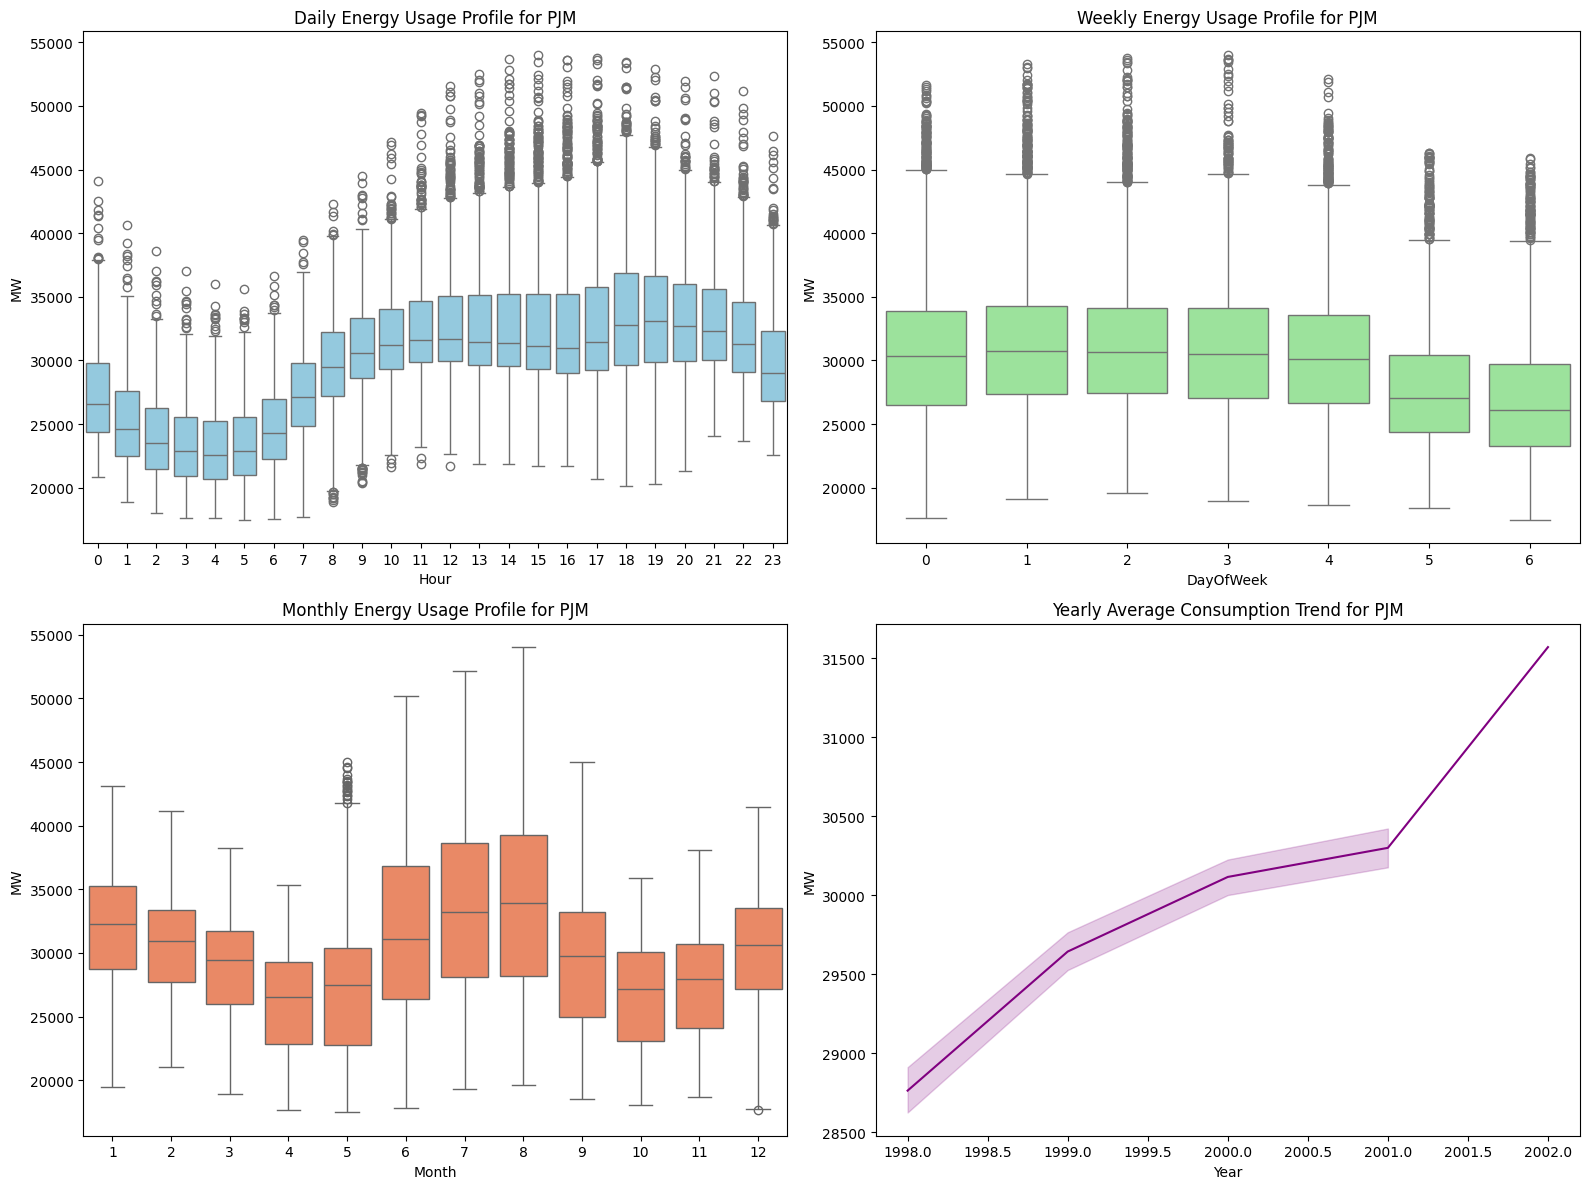


--- Analysis Numbers for PJM ---
Hourly Average MW:


Hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
MW,27346.36,25255.37,24078.26,23455.98,23160.22,23391.28,24672.31,27158.38,29296.55,30663.8,...,32716.88,32613.25,32564.34,32927.25,33669.78,33674.08,33329.74,33125.15,32147.93,29854.06



Day of Week Average MW (0=Monday):


DayOfWeek,0,1,2,3,4,5,6
MW,30531.31,31106.9,31042.41,30816.56,30422.71,27693.49,26753.3



Monthly Average MW:


Month,1,2,3,4,5,6,7,8,9,10,11,12
MW,31943.79,30577.3,28898.51,26104.9,26983.84,31703.03,33573.78,34012.36,29433.19,26655.0,27448.73,30292.88



Yearly Average MW:


Year,1998,1999,2000,2001,2002
MW,28761.83,29642.06,30114.33,30298.45,31569.0


In [2]:
# 2. Extracting Time Features & Seasonal Analysis
energy_df['Hour'] = energy_df.index.hour
energy_df['DayOfWeek'] = energy_df.index.dayofweek
energy_df['Month'] = energy_df.index.month
energy_df['Year'] = energy_df.index.year

def plot_seasonalities(df, region=None):
    data_to_plot = df[df['Region'] == region] if region else df
    title_suffix = f" for {region}" if region else " (All Regions)"
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Daily Usage (Hourly Profile)
    sns.boxplot(data=data_to_plot, x='Hour', y='MW', ax=axes[0, 0], color='skyblue')
    axes[0, 0].set_title(f'Daily Energy Usage Profile{title_suffix}')
    
    # Weekly Usage (0=Monday, 6=Sunday)
    sns.boxplot(data=data_to_plot, x='DayOfWeek', y='MW', ax=axes[0, 1], color='lightgreen')
    axes[0, 1].set_title(f'Weekly Energy Usage Profile{title_suffix}')
    
    # Monthly Usage
    sns.boxplot(data=data_to_plot, x='Month', y='MW', ax=axes[1, 0], color='coral')
    axes[1, 0].set_title(f'Monthly Energy Usage Profile{title_suffix}')
    
    # Yearly Trend
    sns.lineplot(data=data_to_plot, x='Year', y='MW', ax=axes[1, 1], estimator='mean', color='purple')
    axes[1, 1].set_title(f'Yearly Average Consumption Trend{title_suffix}')
    
    plt.tight_layout()
    plt.show()

# Run the analysis for a specific region
available_regions = energy_df['Region'].unique()
if len(available_regions) > 0:
    plot_seasonalities(energy_df, region=available_regions[0])
    # OUTPUT ANALYSIS NUMBERS
    print(f"\n--- Analysis Numbers for {available_regions[0]} ---")
    data_region = energy_df[energy_df['Region'] == available_regions[0]]
    from IPython.display import display
    print("Hourly Average MW:")
    display(data_region.groupby('Hour')['MW'].mean().round(2).to_frame().T)
    print("\nDay of Week Average MW (0=Monday):")
    display(data_region.groupby('DayOfWeek')['MW'].mean().round(2).to_frame().T)
    print("\nMonthly Average MW:")
    display(data_region.groupby('Month')['MW'].mean().round(2).to_frame().T)
    print("\nYearly Average MW:")
    display(data_region.groupby('Year')['MW'].mean().round(2).to_frame().T)


### Step 3: SMA, EMA, and Error Evaluation

Building on your existing notebook structure, here is how you calculate the Moving Averages, visualize them against the actual data, and calculate the Mean Absolute Error (MAE).

PJM - SMA (30-Day) Mean Absolute Error: 2398.16 MW
PJM - EMA (30-Day) Mean Absolute Error: 2246.02 MW

--- SMA & EMA Data Sample (Last 5 Days) for PJM ---


,MW,SMA_30,EMA_30
Datetime,,,
2001-12-28,32489.88,29297.24,29449.53
2001-12-29,30068.25,29338.45,29489.45
2001-12-30,30958.83,29419.94,29584.25
2001-12-31,32605.33,29668.53,29779.16
2002-01-01,31569.00,29879.16,29894.63


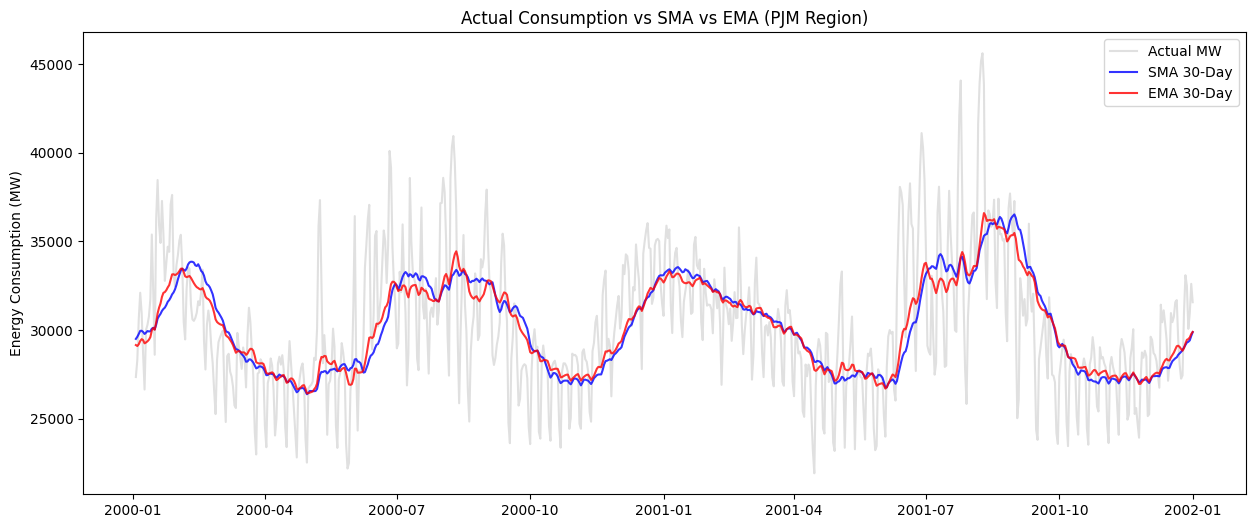

In [3]:
# 3. SMA, EMA, and Error Evaluation
if len(available_regions) > 0:
    region_to_eval = available_regions[0]
    region_df = energy_df[energy_df['Region'] == region_to_eval][['MW']].copy()

    # Resample to daily averages for clarity
    region_daily = region_df.resample('D').mean()

    # Calculate 30-day SMA and EMA
    window = 30
    region_daily['SMA_30'] = region_daily['MW'].rolling(window=window).mean()
    region_daily['EMA_30'] = region_daily['MW'].ewm(span=window, adjust=False).mean()

    # Drop NaNs for error calculation
    eval_df = region_daily.dropna()

    # Calculate MAE
    mae_sma = mean_absolute_error(eval_df['MW'], eval_df['SMA_30'])
    mae_ema = mean_absolute_error(eval_df['MW'], eval_df['EMA_30'])

    print(f"{region_to_eval} - SMA (30-Day) Mean Absolute Error: {mae_sma:.2f} MW")
    print(f"{region_to_eval} - EMA (30-Day) Mean Absolute Error: {mae_ema:.2f} MW")

    # Visualization
    plt.figure(figsize=(15, 6))
    subset = region_daily.iloc[-730:] # Last 2 years
    plt.plot(subset.index, subset['MW'], label='Actual MW', color='lightgrey', alpha=0.7)
    plt.plot(subset.index, subset['SMA_30'], label='SMA 30-Day', color='blue', alpha=0.8)
    plt.plot(subset.index, subset['EMA_30'], label='EMA 30-Day', color='red', alpha=0.8)
    plt.title(f'Actual Consumption vs SMA vs EMA ({region_to_eval} Region)')
    plt.ylabel('Energy Consumption (MW)')
    plt.legend()
    print(f"\n--- SMA & EMA Data Sample (Last 5 Days) for {region_to_eval} ---")
    display(subset[['MW', 'SMA_30', 'EMA_30']].tail(5).round(2))
    plt.show()

### Step 4: Forecasting with Facebook Prophet

Prophet is incredibly powerful for this exact type of data because it natively models daily, weekly, and yearly seasonality. Prophet requires columns to be strictly named `ds` (datetime) and `y` (target variable).

01:46:57 - cmdstanpy - INFO - Chain [1] start processing
01:46:58 - cmdstanpy - INFO - Chain [1] done processing


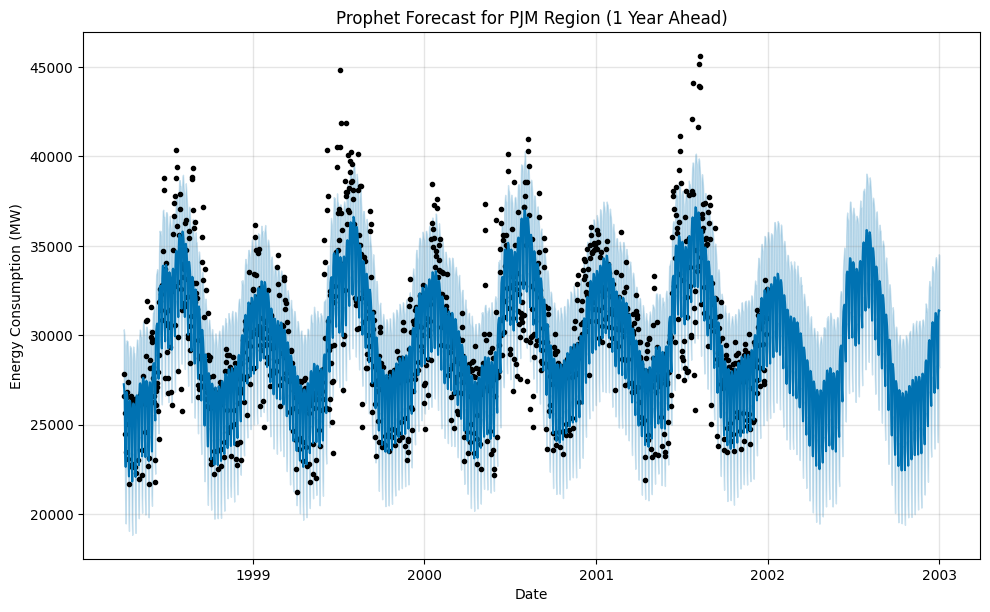

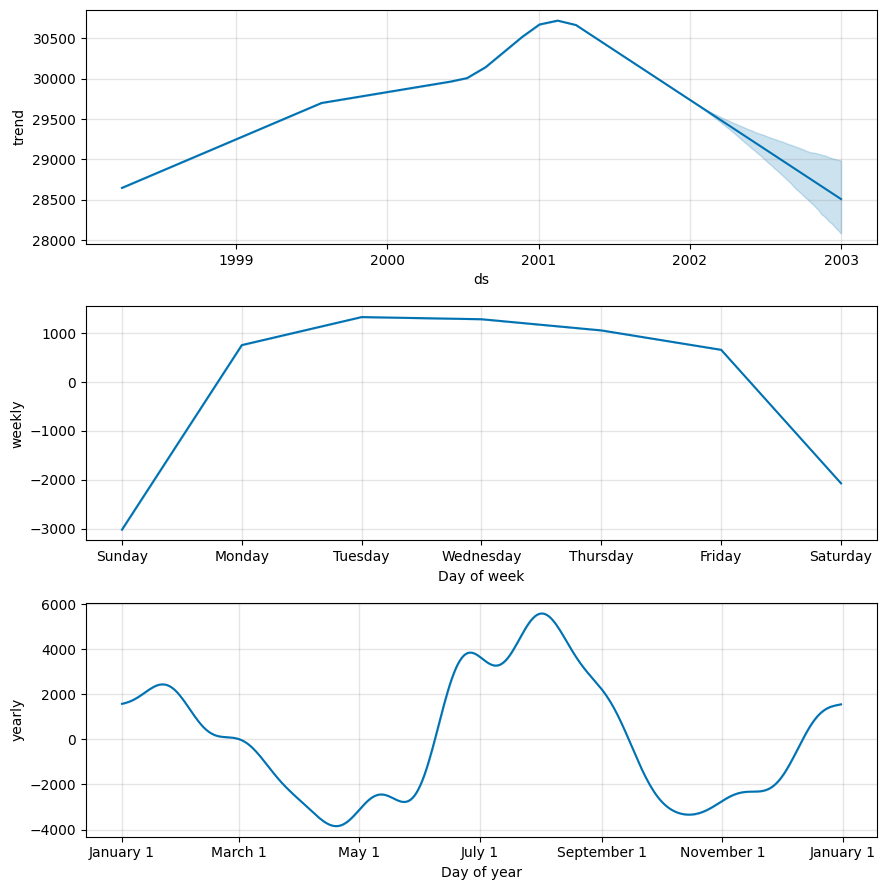


--- Forecast Numbers for PJM (Next 5 Days) ---


,ds,yhat,yhat_lower,yhat_upper
1732,2002-12-28,27950.01,24742.90,30820.58
1733,2002-12-29,27017.89,24016.37,30082.15
1734,2002-12-30,30811.18,27836.80,33878.82
1735,2002-12-31,31398.52,28309.79,34523.67
1736,2003-01-01,31368.31,28195.26,34477.74


In [4]:
# 4. Forecasting with Facebook Prophet
if len(available_regions) > 0:
    prophet_df = region_daily.reset_index()
    prophet_df = prophet_df[['Datetime', 'MW']]
    prophet_df.columns = ['ds', 'y']

    # Initialize and fit the model
    model = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
    model.fit(prophet_df)

    # Create a future dataframe for 1 year
    future = model.make_future_dataframe(periods=365)
    forecast = model.predict(future)

    # Plot the forecast
    fig1 = model.plot(forecast)
    plt.title(f'Prophet Forecast for {region_to_eval} Region (1 Year Ahead)')
    plt.xlabel('Date')
    plt.ylabel('Energy Consumption (MW)')
    plt.show()

    # Plot the individual seasonal components
    fig2 = model.plot_components(forecast)
    plt.show()

    # OUTPUT ANALYSIS NUMBERS FOR FORECAST
    print(f"\n--- Forecast Numbers for {region_to_eval} (Next 5 Days) ---")
    display(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(5).round(2))


### Step 5: Regional Comparisons

To compare how different regions scale against each other over time.

C:\Users\Abdelrahman\AppData\Local\Temp\ipykernel_5932\4207803884.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_regional = energy_df.groupby(['Region', pd.Grouper(freq='M')])['MW'].mean().reset_index()



--- Average Monthly Energy Consumption by Region (Last 5 Months) ---


Region,AEP,COMED,DAYTON,DEOK,DOM,DUQ,EKPC,FE,NI,PJM,PJME,PJMW
Datetime,,,,,,,,,,,,
2018-04-30,13639.24,10140.47,1843.08,2661.07,9526.20,1400.42,1351.07,7154.14,NaN,NaN,27353.27,5281.28
2018-05-31,14117.01,10852.91,1969.06,3178.11,10869.83,1567.37,1372.92,7303.54,NaN,NaN,28599.95,5278.62
2018-06-30,15305.25,12127.77,2117.93,3468.67,12118.39,1671.68,1536.53,7974.29,NaN,NaN,32014.47,5559.33
2018-07-31,15926.62,13312.62,2149.51,3577.92,12798.52,1865.29,1600.67,8652.77,NaN,NaN,36696.74,5978.73
2018-08-31,15406.96,13278.90,2112.78,3405.63,13232.53,1737.06,1471.22,8372.73,NaN,NaN,39331.80,5874.35


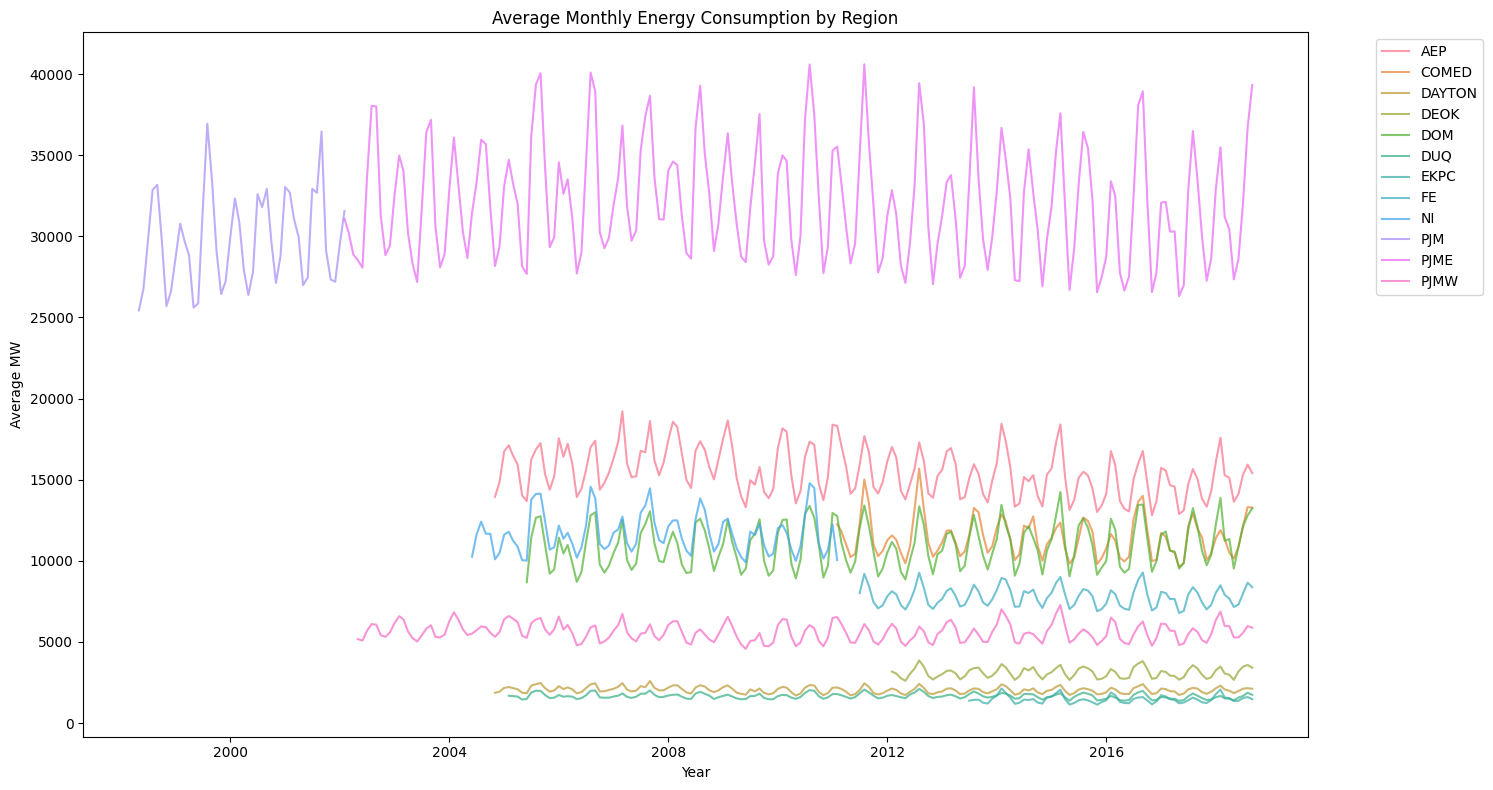

In [5]:
# 5. Regional Comparisons
monthly_regional = energy_df.groupby(['Region', pd.Grouper(freq='M')])['MW'].mean().reset_index()

# OUTPUT ANALYSIS NUMBERS FOR REGIONAL COMPARISONS
print("\n--- Average Monthly Energy Consumption by Region (Last 5 Months) ---")
pivot_regional = monthly_regional.pivot(index='Datetime', columns='Region', values='MW')
from IPython.display import display
display(pivot_regional.tail(5).round(2))

plt.figure(figsize=(15, 8))
sns.lineplot(data=monthly_regional, x='Datetime', y='MW', hue='Region', alpha=0.7)
plt.title('Average Monthly Energy Consumption by Region')
plt.ylabel('Average MW')
plt.xlabel('Year')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()